lane intersections structure  
* key: vehicle num  
* val[i][0]: frame num  
* val[i][1]: vehicle 좌표  
* val[i][2:]: vehicle 좌표에서 수평선을 그었을 때 차선과의 교점  
모든 좌표는 lane net 결과 기준 (512, 256)

depth_map_list
* 150개의 이미지에 대한 1080 * 1920 픽셀의 depth map 값이 3중 리스트로 만들어져 있음

In [38]:
import json
import numpy as np
import os

with open('content/result.json', 'r') as file:
    lane_intersections = json.load(file)
print(lane_intersections)

def load_npy_files(directory):
    npy_files = [f for f in os.listdir(directory) if f.endswith('metric_depth.npy')]
    data_list = []
    for file in npy_files:
        data = np.load(os.path.join(directory, file))
        data_list.append(data)
    return data_list

directory_path = 'content/object_depths'
depth_map_list = load_npy_files(directory_path)

{'vehicle0': [[0, [118, 280], [118, 237.0], [118, 266.5], [118, 289.5]], [1, [118, 280], [118, 236.5], [118, 266.0], [118, 289.5]], [2, [119, 280], [119, 236.5], [119, 267.0], [119, 291.5]], [3, [119, 281], [119, 235.5], [119, 268.0], [119, 292.0]], [5, [119, 281], [119, 234.0], [119, 267.5], [119, 291.0]], [6, [119, 282], [119, 235.0], [119, 265.5], [119, 290.0]], [7, [119, 282], [119, 236.5], [119, 265.0], [119, 292.5]], [8, [119, 283], [119, 236.5], [119, 266.5], [119, 292.5]], [9, [119, 283], [119, 237.5], [119, 267.5], [119, 291.0]], [10, [119, 283], [119, 236.0], [119, 267.0], [119, 290.0]], [11, [119, 284], [119, 235.0], [119, 268.0], [119, 292.5]], [12, [119, 284], [119, 230.0], [119, 266.5], [119, 290.5]], [13, [119, 285], [119, 233.5], [119, 267.0], [119, 291.5]], [14, [119, 285], [119, 229.0], [119, 266.0], [119, 291.0]], [15, [119, 285], [119, 225.5], [119, 267.5], [119, 293.0]], [17, [119, 286], [119, 234.0], [119, 266.5], [119, 292.5]], [18, [119, 287], [119, 234.5], [119

In [39]:
# resizing 
lheight, lwidth =  256, 512 # lane net size
dheight, dwidth = depth_map_list[0].shape # depth map size

print(f"lanenet size: {lheight, lwidth}")
print(f"depth map size: {dheight, dwidth}")

resizing_val = dheight/lheight, dwidth/lwidth
print(f"resizing value: {resizing_val}")

lanenet size: (256, 512)
depth map size: (1080, 1920)
resizing value: (4.21875, 3.75)


In [40]:
for vehicle, values in lane_intersections.items():
    print(f"{vehicle}: {len(values)}")
    for value in values:
        for points in value[1:]:
            # if points[0]>lheight or points[1]>lwidth:
            #     print(vehicle, points[0], points[1], lheight, lwidth)
            #     break
            points[0] *= resizing_val[0]
            points[1] *= resizing_val[1]
            # if points[0]>dheight or points[1]>dwidth:
            #     print(vehicle, points[0], points[1], dheight, dwidth)
            #     break

vehicle0: 118
vehicle1: 77
vehicle8: 32
vehicle10: 7
vehicle13: 20
vehicle16: 8
vehicle19: 13
vehicle25: 3
vehicle27: 3
vehicle28: 2
vehicle29: 15
vehicle31: 13
vehicle36: 11


In [41]:
fx, fy, cx, cy = 1316.81, 738.72, 960, 540
def get_3dpoint(frame_num, v, u):
    depth = depth_map_list[frame_num]
    d = depth[v,u]
    Z = d
    X = (v - cx) * Z / fx
    Y = (u - cy) * Z / fy
    return [X, Y, Z]

### 교점 확인  
이미지에 교점 직접 찍어봄

In [42]:
idx=0
print(lane_intersections.keys())
vehicle = 'vehicle0'

dict_keys(['vehicle0', 'vehicle1', 'vehicle8', 'vehicle10', 'vehicle13', 'vehicle16', 'vehicle19', 'vehicle25', 'vehicle27', 'vehicle28', 'vehicle29', 'vehicle31', 'vehicle36'])


In [43]:
import cv2

img_path = f'content/tracker/000001.png'
img = cv2.imread(img_path)
print(img.shape)

(1080, 1920, 3)


1
497 1050
[np.float64(-11.78433360193042), np.float64(23.13862098190793), np.float64(33.5156119446177)]
497 886
[np.float64(-11.064671847228725), np.float64(14.73930157272109), np.float64(31.468834849134463)]
497 997
[np.float64(-11.377164680756188), np.float64(20.017623297834465), np.float64(32.357590115046555)]
497 1085
[np.float64(-11.747853230429133), np.float64(24.650020348480176), np.float64(33.411858773998674)]


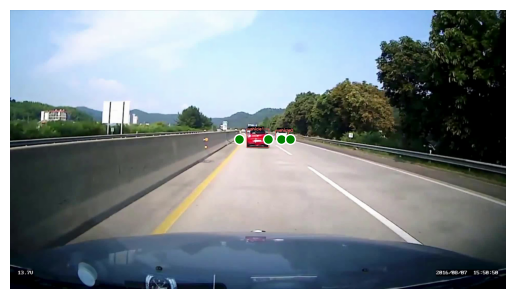

In [44]:
import random
import cv2
import matplotlib.pyplot as plt
#idx = random.randint(0, tracking_len-1)
#print(idx)

idx += 1
print(idx)

frame_num = lane_intersections[vehicle][idx][0]
img_path = f'content/tracker/{frame_num:06d}.png'
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

for point in lane_intersections[vehicle][idx][1:]:
    v, u = int(point[0]), int(point[1])
    plt.scatter([u], [v], color='green', s=50, edgecolor='white')
    print(v, u)
    print(get_3dpoint(frame_num, v, u))

plt.axis('off')
plt.show()

[[527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [518.90625, 952.5], [518.90625, 952.5], [518.90625, 952.5], [518.90625, 948.75], [518.90625, 948.75], [518.90625, 948.75], [518.90625, 948.75], [518.90625, 948.75], [518.90625, 945.0], [523.125, 945.0], [523.125, 945.0], [523.125, 945.0], [523.125, 945.0], [523.125, 945.0], [518.90625, 945.0], [523.1

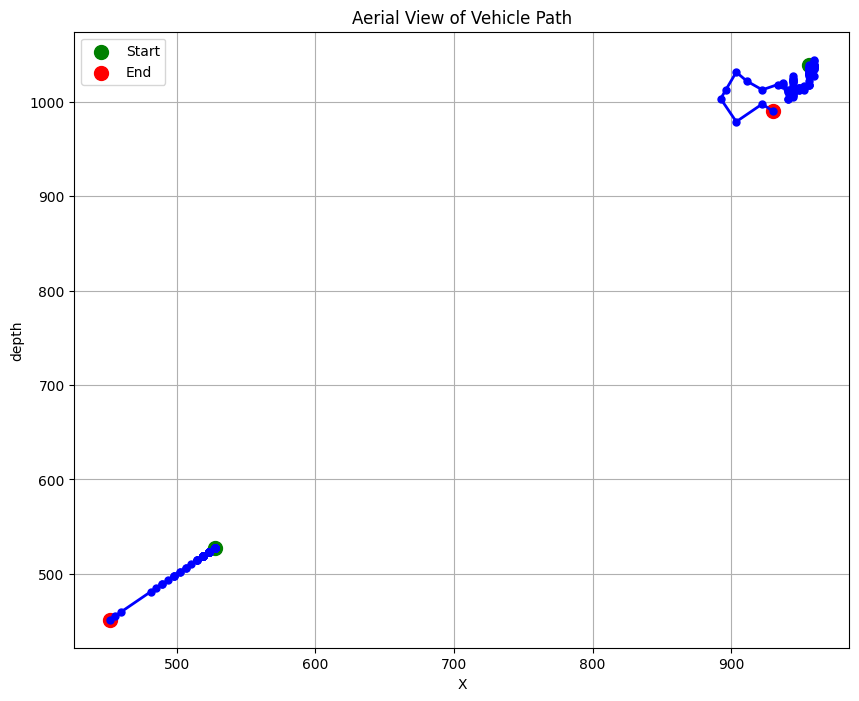

In [45]:
import matplotlib.pyplot as plt

vehicle = 'vehicle1'
points = lane_intersections[vehicle][:]

x = [point[1] for point in points]
y = [point[2] for point in points]
z = [point[3] for point in points]
print(x)
print(y)
print(z)

plt.figure(figsize=(10, 8))
plt.plot(x, z, marker='o', color='b', linestyle='-', linewidth=2, markersize=5)

plt.scatter(x[0], z[0], color='g', s=100, label='Start')
plt.scatter(x[-1], z[-1], color='r', s=100, label='End')

plt.xlabel('X')
plt.ylabel('depth')

plt.title('Aerial View of Vehicle Path')

plt.legend()

plt.grid(True)
plt.show()


In [46]:
# vehicle당 모든 [frame_num, vehicle coor, lane coors] 계산
# depth map size: (1080, 1920)
realworld_values = {}
for vehicle, values in lane_intersections.items():
    points3d = []
    for value in values:
        frame_num = value[0]
        point3d = [frame_num]
        for points in value[1:]:
            point3d.append(get_3dpoint(frame_num, int(points[0]), int(points[1])))
        points3d.append(point3d)
    realworld_values[vehicle] = points3d

차선이 여러 개 있을 때, 차선 사이 폭이 모두 똑같다고 가정  
frame마다 value가 있고, 차선 사이 폭의 평균 계산 -> average_width    
계산된 frame당 평균 차선 폭의 평균을 구함  


In [47]:
# lane width 계산
lane_widths_dict = {}

for vehicle, values in realworld_values.items():
    all_widths = []
    for frame_value in values:
        lane_num = len(frame_value)-2
        frame_widths = []
        # 차선의 좌표들로 차선 폭 계산
        for idx in range(lane_num-1):
            # print(idx, len(frame_value), vehicle, frame_value)
            frame_width = np.linalg.norm(np.array(frame_value[idx+2]) - np.array(frame_value[idx+3])) # frame num, vehicle coor 제외  
            frame_widths.append(frame_width)
        all_widths.append(np.mean(frame_widths))
    lane_widths_dict[vehicle] = np.mean(all_widths)

/home/dgist/.local/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dgist/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [48]:
from scipy.stats import mode
import numpy as np

# lane width 계산
lane_widths_dict = {}

for vehicle, values in realworld_values.items():
    all_widths = []
    for frame_value in values:
        lane_num = len(frame_value) - 2
        # 차선의 좌표들로 차선 폭 계산
        for idx in range(lane_num - 1):
            frame_width = np.linalg.norm(np.array(frame_value[idx+2]) - np.array(frame_value[idx+3])) # frame num, vehicle coor 제외
            all_widths.append(frame_width)
    
    # all_widths에서 최빈값 계산
    if len(all_widths) > 0:
        mode_result = mode(all_widths)
        print(vehicle, mode_result)
        print(mode_result)  # mode_result의 구조를 확인합니다
        if mode_result.mode.size > 0:  # mode_result.mode가 빈 배열이 아닌지 확인
            lane_widths_dict[vehicle] = mode_result.mode
        else:
            lane_widths_dict[vehicle] = None  # 최빈값이 없는 경우 처리
    else:
        lane_widths_dict[vehicle] = None  # 데이터가 없는 경우 처리

# print(lane_widths_dict)


vehicle0 ModeResult(mode=np.float64(3.2010419049344363), count=np.int64(1))
ModeResult(mode=np.float64(3.2010419049344363), count=np.int64(1))
vehicle1 ModeResult(mode=np.float64(3.518844856363452), count=np.int64(1))
ModeResult(mode=np.float64(3.518844856363452), count=np.int64(1))
vehicle8 ModeResult(mode=np.float64(3.22196833467847), count=np.int64(1))
ModeResult(mode=np.float64(3.22196833467847), count=np.int64(1))
vehicle13 ModeResult(mode=np.float64(2.831322605740157), count=np.int64(1))
ModeResult(mode=np.float64(2.831322605740157), count=np.int64(1))
vehicle16 ModeResult(mode=np.float64(2.2822987946975624), count=np.int64(1))
ModeResult(mode=np.float64(2.2822987946975624), count=np.int64(1))
vehicle19 ModeResult(mode=np.float64(2.171412390412887), count=np.int64(1))
ModeResult(mode=np.float64(2.171412390412887), count=np.int64(1))
vehicle27 ModeResult(mode=np.float64(6.625739499846233), count=np.int64(1))
ModeResult(mode=np.float64(6.625739499846233), count=np.int64(1))
vehicle

In [49]:
lane_widths_dict
valid_values = [value for value in lane_widths_dict.values() if value is not None]
lane_width = np.median(valid_values)


for i in lane_widths_dict.keys():
    if lane_widths_dict[i]==None:
        lane_widths_dict[i]=lane_width



차량 위치 계산  
1. 차량이 차선 사이에 위치 : 차량 x좌표가 min도 아니고 max도 아님    
2. 차량이 가장자리에 위치 : 차량 x좌표가 min혹은 max  

In [50]:
for key, value in lane_intersections.items():
    print(key)

vehicle0
vehicle1
vehicle8
vehicle10
vehicle13
vehicle16
vehicle19
vehicle25
vehicle27
vehicle28
vehicle29
vehicle31
vehicle36


In [51]:
lane_ratios = {}
for vehicle, values in lane_intersections.items():
    vehicle_lane_ratios = []
    for value in values:
        frame_num = value[0]
        x = sorted(value[1:], key=lambda x: x[1])
        for vehicle_idx in range(len(x)):
            if value[1][1] == x[vehicle_idx][1]:
                break
        if vehicle_idx==0:
            # 차량이 왼쪽 끝에 위치
            if (len(x)<=1):
                continue

            else :
                lane1 = get_3dpoint(frame_num, int(x[vehicle_idx+1][0]), int(x[vehicle_idx+1][1]))
                vehicle_point = get_3dpoint(frame_num, int(value[1][0]), int(value[1][1]))

                lane_width = lane_widths_dict[vehicle]
                ratio2 = np.linalg.norm(np.array(vehicle_point) - np.array(lane1)) / lane_width
                ratio1 = 1-ratio2

                if ratio1 < 0 or ratio2 < 0:
                    print(f"{vehicle} {frame_num}: ratio1={ratio1}, ratio2={ratio2}/ {lane_width}")

                vehicle_lane_ratios.append([frame_num, vehicle_idx, ratio1, ratio2])

        elif vehicle_idx==len(x)-1:



            # 차량이 오른쪽 끝에 위치
            lane1 = get_3dpoint(frame_num, int(x[vehicle_idx-1][0]), int(x[vehicle_idx-1][1]))
            vehicle_point = get_3dpoint(frame_num, int(value[1][0]), int(value[1][1]))

            lane_width = lane_widths_dict[vehicle]
            ratio1 = np.linalg.norm(np.array(vehicle_point) - np.array(lane1)) / lane_width
            ratio2 = 1-ratio1

            if ratio1 < 0 or ratio2 < 0:
                print(f"{vehicle} {frame_num}: ratio1={ratio1}, ratio2={ratio2}/ {lane_width}")

            vehicle_lane_ratios.append([frame_num, vehicle_idx, ratio1, ratio2])

        else:

            lane1 = get_3dpoint(frame_num, int(x[vehicle_idx-1][0]), int(x[vehicle_idx-1][1]))
            lane2 = get_3dpoint(frame_num, int(x[vehicle_idx+1][0]), int(x[vehicle_idx+1][1]))
            vehicle_point = get_3dpoint(frame_num, int(value[1][0]), int(value[1][1]))

            lane_width = np.linalg.norm(np.array(lane2) - np.array(lane1))
            ratio1 = np.linalg.norm(np.array(vehicle_point) - np.array(lane1)) / lane_width
            ratio2 = np.linalg.norm(np.array(lane2) - np.array(vehicle_point)) / lane_width
            
            ratio_sum = ratio1+ratio2
            ratio1 = ratio1/ratio_sum
            ratio2 = ratio2/ratio_sum
            if ratio1 < 0 or ratio2 < 0:
                print(f"{vehicle} {frame_num}: ratio1={ratio1}, ratio2={ratio2}/ {lane_width}")

            vehicle_lane_ratios.append([frame_num, vehicle_idx, ratio1, ratio2])
    lane_ratios[vehicle] = vehicle_lane_ratios
        

vehicle0 33: ratio1=2.45700466744284, ratio2=-1.45700466744284/ 3.2010419049344363
vehicle0 38: ratio1=1.0734759569031416, ratio2=-0.07347595690314157/ 3.2010419049344363
vehicle0 42: ratio1=1.6606211744956443, ratio2=-0.6606211744956443/ 3.2010419049344363
vehicle0 45: ratio1=2.5357158987079353, ratio2=-1.5357158987079353/ 3.2010419049344363
vehicle0 47: ratio1=1.127606922344858, ratio2=-0.12760692234485793/ 3.2010419049344363
vehicle0 50: ratio1=2.9941627249441263, ratio2=-1.9941627249441263/ 3.2010419049344363
vehicle0 53: ratio1=3.807670754790258, ratio2=-2.807670754790258/ 3.2010419049344363
vehicle0 114: ratio1=1.3005325182388567, ratio2=-0.30053251823885674/ 3.2010419049344363
vehicle0 120: ratio1=1.4452039756365629, ratio2=-0.4452039756365629/ 3.2010419049344363
vehicle0 122: ratio1=1.5484390196342552, ratio2=-0.5484390196342552/ 3.2010419049344363
vehicle0 123: ratio1=1.3670597160984694, ratio2=-0.36705971609846944/ 3.2010419049344363
vehicle0 124: ratio1=2.083154541542009, ra

In [52]:
lane_ratios

{'vehicle0': [[0,
   2,
   np.float64(0.7746502113158782),
   np.float64(0.22534978868412184)],
  [1, 2, np.float64(0.6887738671199884), np.float64(0.31122613288001155)],
  [2, 2, np.float64(0.7646259554255337), np.float64(0.23537404457446628)],
  [3, 2, np.float64(0.29631253500082), np.float64(0.7036874649991799)],
  [5, 2, np.float64(0.7587703283155723), np.float64(0.24122967168442758)],
  [6, 2, np.float64(0.8080197219356186), np.float64(0.19198027806438137)],
  [7, 2, np.float64(0.788248792851245), np.float64(0.21175120714875492)],
  [8, 2, np.float64(0.6218662707935823), np.float64(0.3781337292064177)],
  [9, 2, np.float64(0.8886148492804168), np.float64(0.11138515071958317)],
  [10, 2, np.float64(0.6181074587973534), np.float64(0.3818925412026466)],
  [11, 2, np.float64(0.8313968472141211), np.float64(0.16860315278587878)],
  [12, 2, np.float64(0.5188283574248463), np.float64(0.48117164257515366)],
  [13, 2, np.float64(0.616895355001692), np.float64(0.3831046449983081)],
  [14, 2

### 비율 음수인 경우 주변값의 평균값으로 값 대체
값이 음수이거나 lanewidth보다 큰 값일 경우 주변값들의 평균값으로 대체해주었다.

In [53]:

for key, items in lane_ratios.items():
    for i in range(len(lane_ratios[key])):
        if lane_ratios[key][i][2]<0 or lane_ratios[key][i][2]>1:
            index_1=0
            index_2=0
            if i==0:    
                for j in range(i,len(lane_ratios[key])):
                    if 0<lane_ratios[key][j][2]<1:
                        index_1=index_2=j
                        break
            elif i==len(lane_ratios[key])-1:
                for j in range(i-1,0,-1):
                    if 0<lane_ratios[key][j][2]<1:
                        index_1=index_2=j
                        break
            else:
                for j in range(i,len(lane_ratios[key])):
                    if 0<lane_ratios[key][j][2]<1:
                        index_1=j
                        break
                for j in range(i-1,0,-1):
                    if 0<lane_ratios[key][j][2]<1:
                        index_2=j
                        break
            lane_ratios[key][i][2] = (lane_ratios[key][index_1][2] + lane_ratios[key][index_2][2])/2

        if lane_ratios[key][i][3]<0 or lane_ratios[key][i][3]>1:
            index_1=0
            index_2=0
            if i==0:
                for j in range(i,len(lane_ratios[key])):
                    if 0<lane_ratios[key][j][3]<1:
                        index_1=index_2=j
                        break
            elif i==len(lane_ratios[key])-1:
                for j in range(i-1,0,-1):
                    if 0<lane_ratios[key][j][3]<1:
                        index_1=index_2=j
                        break
            else:
                for j in range(i,len(lane_ratios[key])):
                    if 0<lane_ratios[key][j][3]<1:
                        index_1=j
                        break
                for j in range(i-1,0,-1):
                    if 0<lane_ratios[key][j][3]<1:
                        index_2=j
                        break
            lane_ratios[key][i][3] = (lane_ratios[key][index_1][3] + lane_ratios[key][index_2][3])/2    
        


In [54]:
print(lane_width)

4.002275172804704


### 값이 음수가 나오는 차량 찍어보기

In [55]:
for key, items in lane_ratios.items():
    for i in range(len(lane_ratios[key])):
        if lane_ratios[key][i][2]<0 or lane_ratios[key][i][3]<0:
            print(key,": ",lane_ratios[key][i][2], lane_ratios[key][i][3]) 

vehicle10 :  -10.531317647313394 11.531317647313394
vehicle10 :  -10.531317647313394 11.531317647313394
vehicle10 :  -10.531317647313394 11.531317647313394
vehicle10 :  -10.531317647313394 11.531317647313394
vehicle10 :  -10.531317647313394 11.531317647313394
vehicle10 :  -10.531317647313394 11.531317647313394
vehicle16 :  -3.4041424298209506 4.404142429820951
vehicle16 :  -3.4041424298209506 4.404142429820951
vehicle16 :  -3.4041424298209506 4.404142429820951
vehicle16 :  -3.4041424298209506 4.404142429820951
vehicle16 :  -3.4041424298209506 4.404142429820951
vehicle16 :  -3.4041424298209506 4.404142429820951
vehicle16 :  -3.4041424298209506 4.404142429820951
vehicle16 :  -3.4041424298209506 4.404142429820951
vehicle36 :  -7.052279937069333 8.052279937069333
vehicle36 :  -7.052279937069333 8.052279937069333
vehicle36 :  -7.052279937069333 8.052279937069333
vehicle36 :  -7.052279937069333 8.052279937069333
vehicle36 :  -7.052279937069333 8.052279937069333
vehicle36 :  -7.05227993706933

### 일단은 vehicel 0, vehicle 1의 정보만 뽑고 싶어서 아래 과정을 거침

In [65]:
filtered_lane_ratios = {
    "vehicle0": lane_ratios.get("vehicle0"),
    "vehicle1": lane_ratios.get("vehicle1")
}

### lane_postion을 json 파일로 저장

In [56]:
import json
file_path = 'content/lane_ratio.json'
with open(file_path, 'w', encoding='utf-8') as json_file:
            json.dump(lane_ratios, json_file, ensure_ascii=False, indent=4)

### 차선별로 비율을 스무딩하고 그래프 그리기

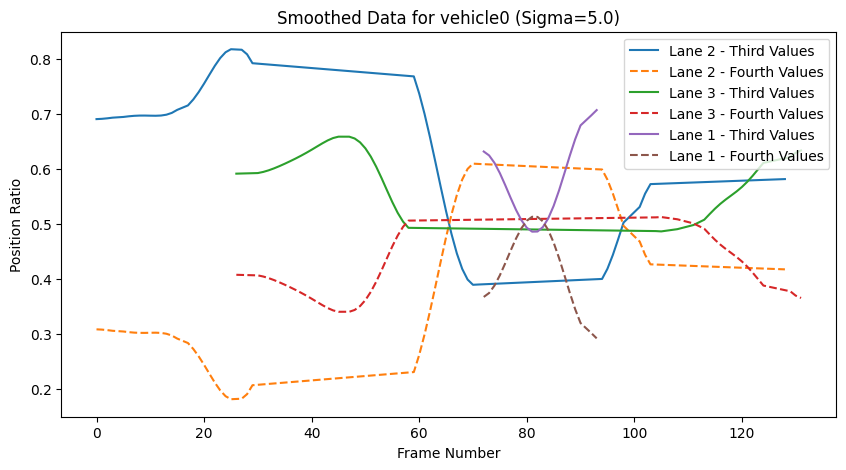

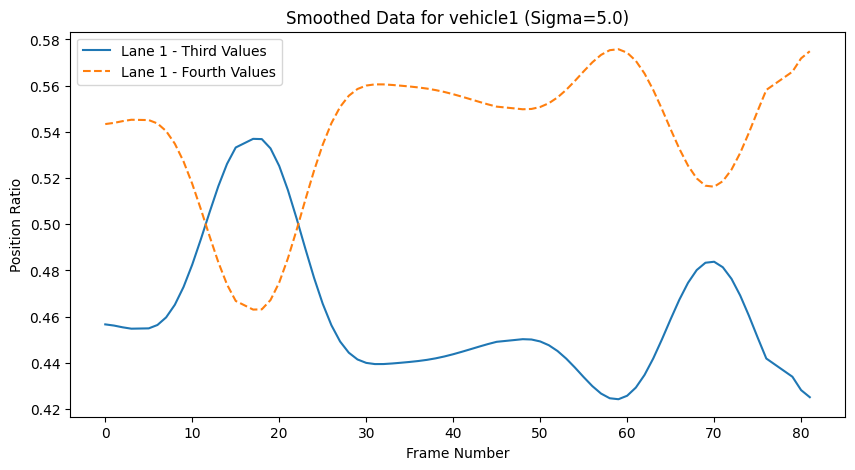

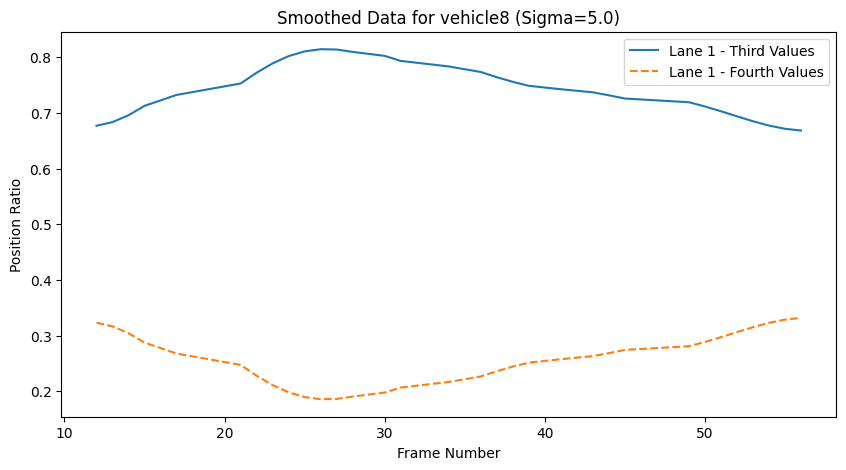

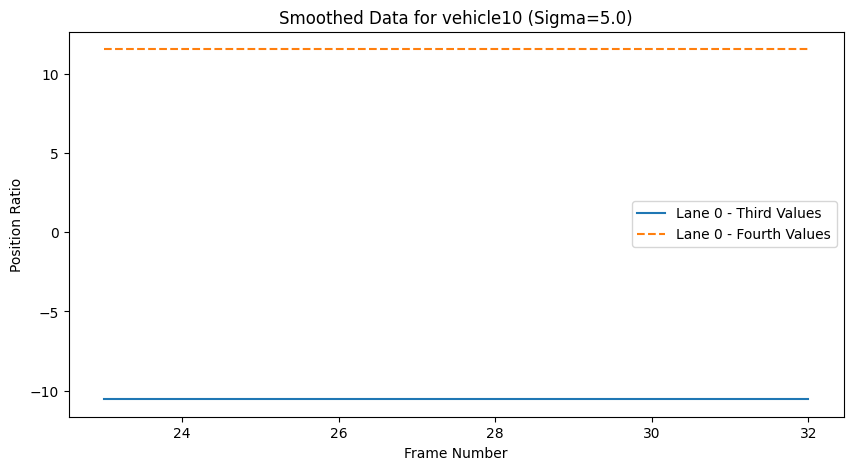

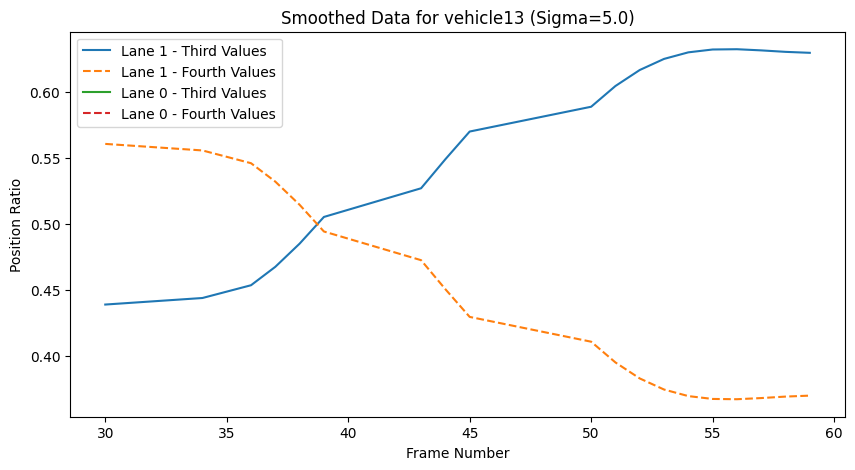

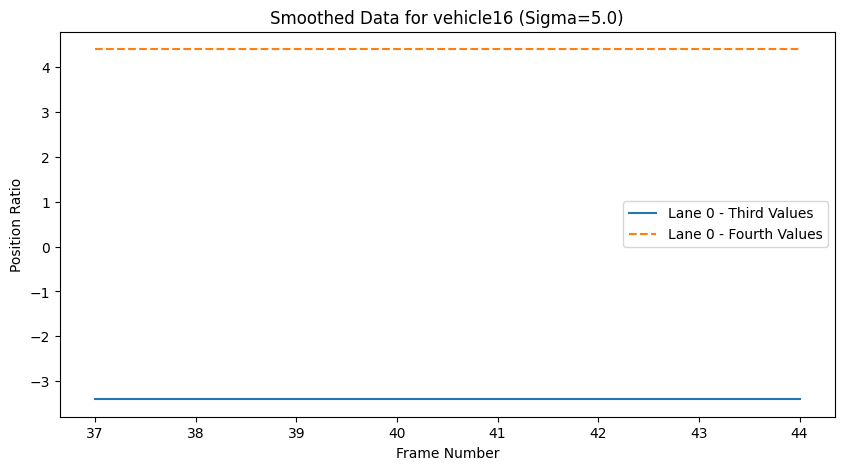

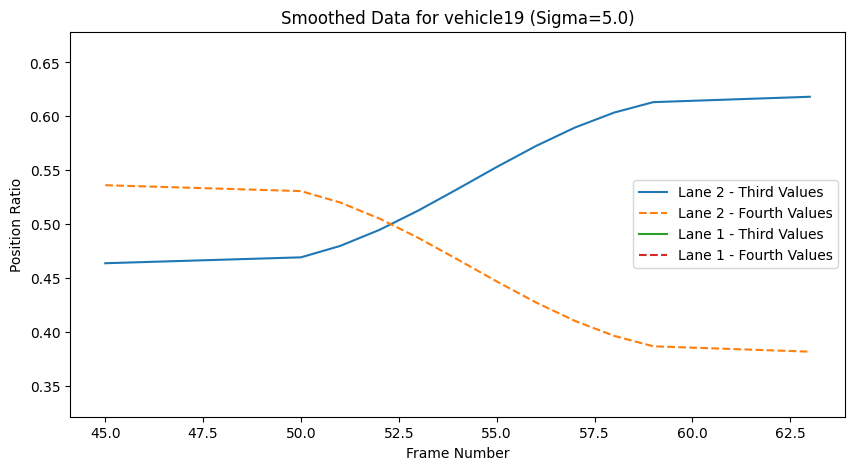

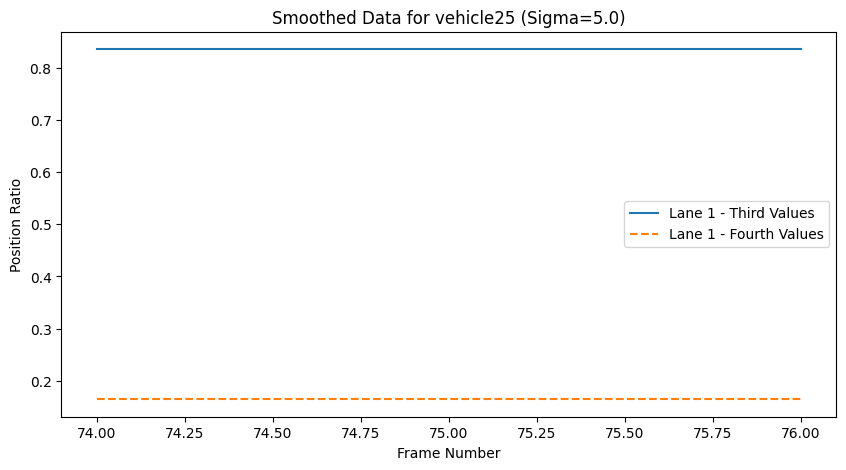

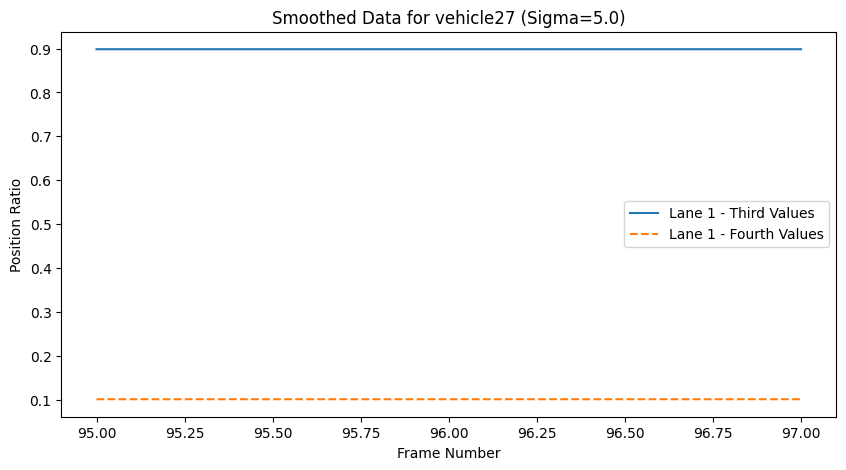

/tmp/ipykernel_4843/2162687858.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


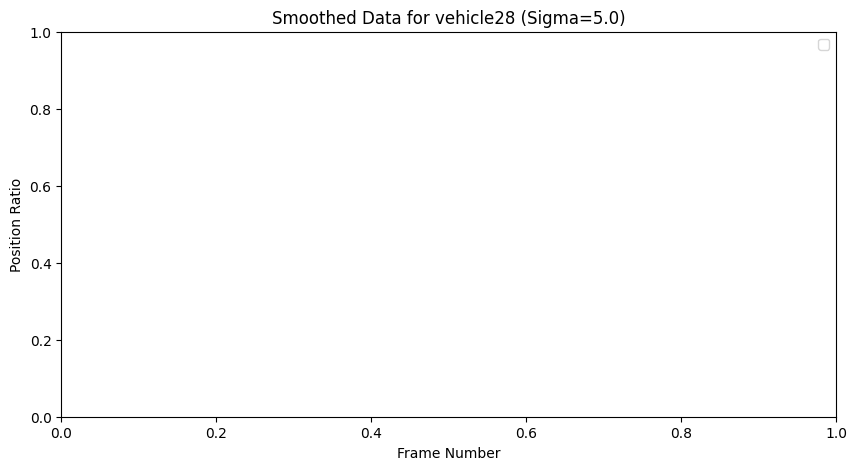

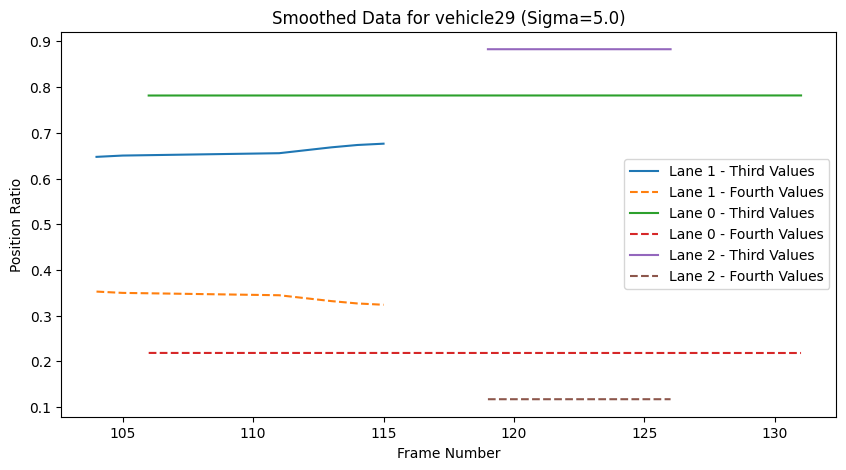

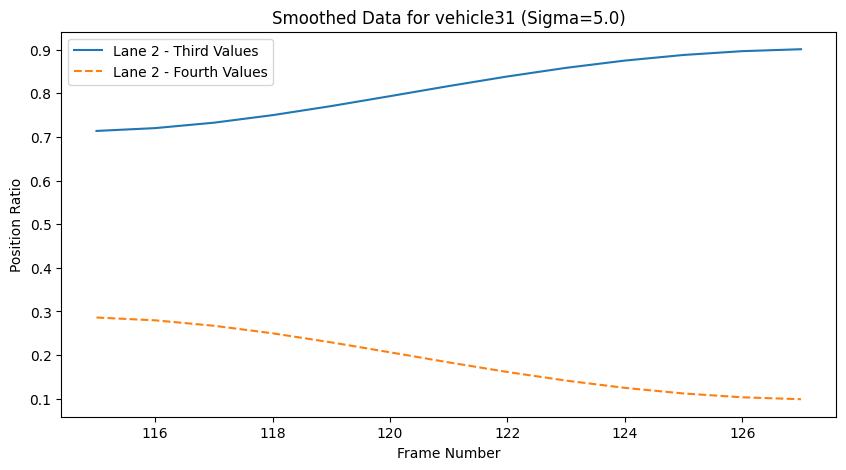

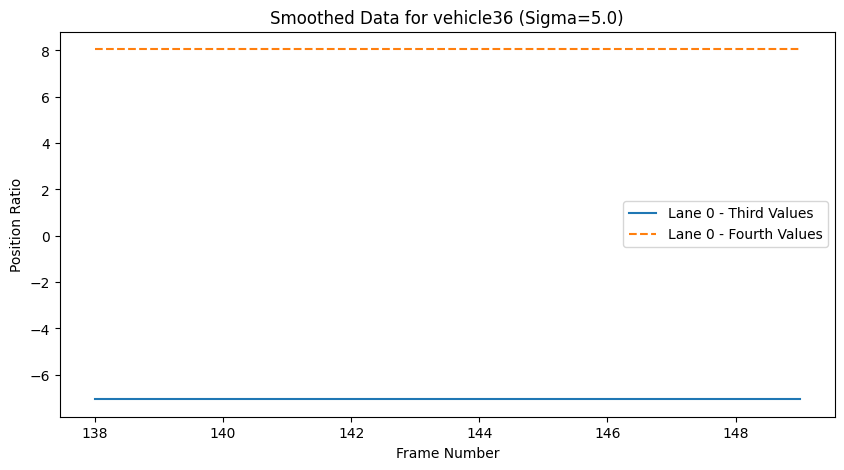

In [57]:
import json
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

# JSON 파일 경로
input_file_path = 'content/lane_ratio.json'
output_file_path = 'content/lane_ratio_smoothed.json'

# 가우시안 필터의 표준 편차 (sigma)
sigma = 5.0

def apply_gaussian_smoothing(vehicle_data, sigma):
    # 차선별로 데이터 그룹화
    lane_groups = {}
    for frame in vehicle_data:
        lane_id = frame[1]
        if lane_id not in lane_groups:
            lane_groups[lane_id] = {'frames': [], 'third_values': [], 'fourth_values': []}
        lane_groups[lane_id]['frames'].append(frame[0])
        lane_groups[lane_id]['third_values'].append(frame[2])
        lane_groups[lane_id]['fourth_values'].append(frame[3])

    # 각 차선에 대해 가우시안 스무딩 적용
    for lane_id, lane_data in lane_groups.items():
        smoothed_third_values = gaussian_filter1d(lane_data['third_values'], sigma=sigma)
        smoothed_fourth_values = gaussian_filter1d(lane_data['fourth_values'], sigma=sigma)
        
        # 스무딩된 값을 원래 데이터에 반영
        for i, frame in enumerate(vehicle_data):
            if frame[1] == lane_id:
                frame[2] = smoothed_third_values[lane_data['frames'].index(frame[0])]
                frame[3] = smoothed_fourth_values[lane_data['frames'].index(frame[0])]

# JSON 파일 읽기
with open(input_file_path, 'r', encoding='utf-8') as json_file:
    data = json.load(json_file)

# 각 차량에 대해 가우시안 스무딩 적용
for vehicle in data:
    apply_gaussian_smoothing(data[vehicle], sigma)

# 스무딩된 데이터를 새로운 JSON 파일로 저장
with open(output_file_path, 'w', encoding='utf-8') as json_file:
    json.dump(data, json_file, ensure_ascii=False, indent=4)

# 그래프 그리기 함수
def plot_smoothed_data(vehicle_data, vehicle_name):
    # 차선별로 데이터를 그룹화하여 그래프 생성
    lane_groups = {}
    for frame in vehicle_data:
        lane_id = frame[1]
        if lane_id not in lane_groups:
            lane_groups[lane_id] = {'frames': [], 'third_values': [], 'fourth_values': []}
        lane_groups[lane_id]['frames'].append(frame[0])
        lane_groups[lane_id]['third_values'].append(frame[2])
        lane_groups[lane_id]['fourth_values'].append(frame[3])

    plt.figure(figsize=(10, 5))
    
    for lane_id, lane_data in lane_groups.items():
        plt.plot(lane_data['frames'], lane_data['third_values'], label=f'Lane {lane_id} - Third Values')
        plt.plot(lane_data['frames'], lane_data['fourth_values'], label=f'Lane {lane_id} - Fourth Values', linestyle='--')

    # 그래프 제목 및 레이블 설정
    plt.title(f'Smoothed Data for {vehicle_name} (Sigma={sigma})')
    plt.xlabel('Frame Number')
    plt.ylabel('Position Ratio')
    plt.legend()

    # 그래프 보여주기
    plt.show()

# 각 차량에 대해 그래프 출력
for vehicle in data:
    plot_smoothed_data(data[vehicle], vehicle)


### 빈값 채우기

In [58]:
import json
import numpy as np

# JSON 파일 경로
input_file_path = 'content/lane_ratio_smoothed.json'
output_file_path = 'content/lane_ratio_filled.json'

def fill_missing_frames(vehicle_data):
    if not vehicle_data:
        # vehicle_data가 빈 리스트일 경우 처리하지 않음
        return
    
    # 프레임 번호를 가져와서 누락된 프레임을 찾습니다.
    frames = [frame[0] for frame in vehicle_data]
    min_frame, max_frame = min(frames), max(frames)
    all_frames = set(range(min_frame, max_frame + 1))
    missing_frames = sorted(all_frames - set(frames))
    
    # 누락된 프레임에 대해 주변값을 사용하여 채웁니다.
    for missing_frame in missing_frames:
        # 채울 값들을 찾습니다.
        prev_frame = max([frame for frame in frames if frame < missing_frame], default=None)
        next_frame = min([frame for frame in frames if frame > missing_frame], default=None)
        
        if prev_frame is not None:
            # 이전 프레임의 값을 사용합니다.
            prev_value = [frame for frame in vehicle_data if frame[0] == prev_frame][0]
            new_frame = [missing_frame, prev_value[1], prev_value[2], prev_value[3]]
        elif next_frame is not None:
            # 다음 프레임의 값을 사용합니다 (이 경우, 처음 프레임이 없을 때만).
            next_value = [frame for frame in vehicle_data if frame[0] == next_frame][0]
            new_frame = [missing_frame, next_value[1], next_value[2], next_value[3]]
        
        # 새로운 데이터를 추가합니다.
        vehicle_data.append(new_frame)
    
    # 프레임 번호를 기준으로 데이터를 정렬합니다.
    vehicle_data.sort(key=lambda x: x[0])

# JSON 파일 읽기
with open(input_file_path, 'r', encoding='utf-8') as json_file:
    data = json.load(json_file)

# 각 차량에 대해 누락된 프레임을 채우기
for vehicle in data:
    fill_missing_frames(data[vehicle])

# 채워진 데이터를 새로운 JSON 파일로 저장
with open(output_file_path, 'w', encoding='utf-8') as json_file:
    json.dump(data, json_file, ensure_ascii=False, indent=4)

print(f"Missing frames filled and saved to {output_file_path}")


Missing frames filled and saved to content/lane_ratio_filled.json


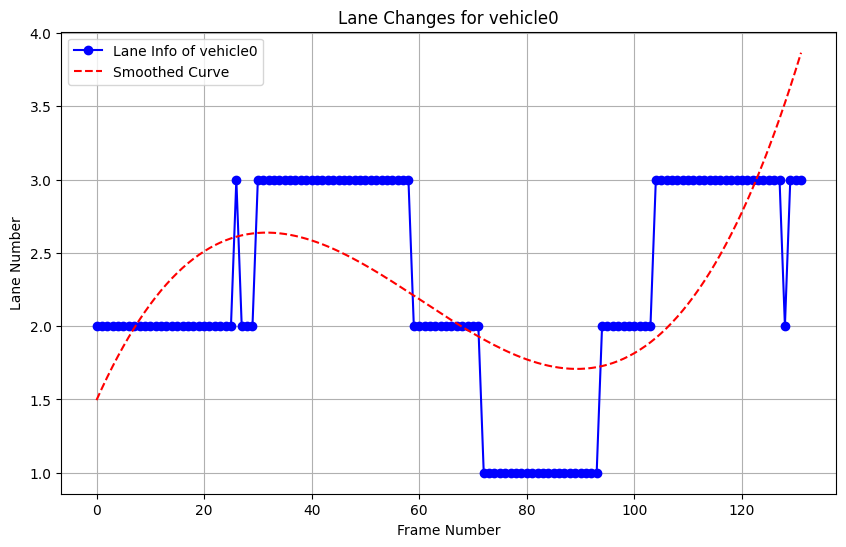

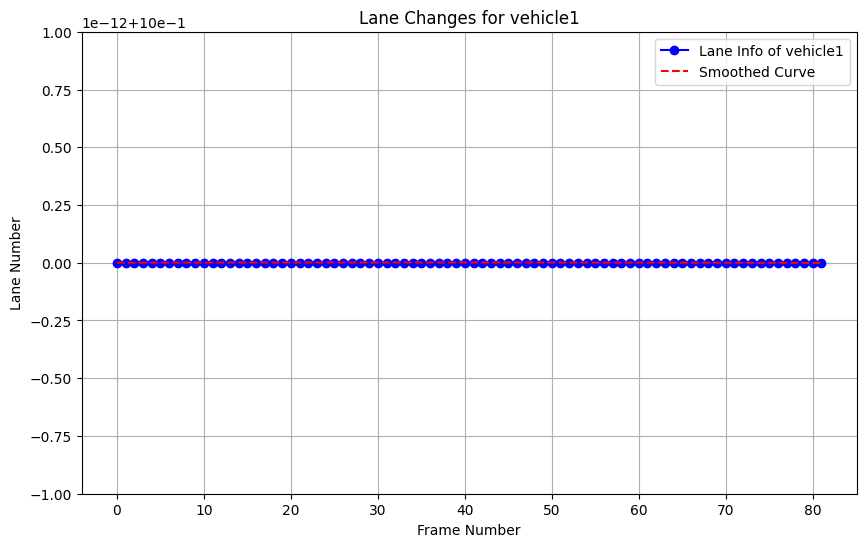

In [59]:
import json
import matplotlib.pyplot as plt
import numpy as np

# JSON 파일에서 데이터를 로드
json_file_path = 'content/lane_ratio_filled.json'

with open(json_file_path, 'r') as f:
    vehicle_data = json.load(f)

# 차량별로 차선 정보만 추출하고 플로팅하는 함수
def plot_lane_changes_from_file(vehicle_data):
    for vehicle, frames in vehicle_data.items():
        frames = np.array(frames)
        frames_num = frames[:, 0]
        lane_info = frames[:, 1]
        
        plt.figure(figsize=(10, 6))
        plt.plot(frames_num, lane_info, marker='o', linestyle='-', color='b', label=f'Lane Info of {vehicle}')
        
        # 부드러운 곡선을 위해 보간
        z = np.polyfit(frames_num, lane_info, 3)
        p = np.poly1d(z)
        plt.plot(frames_num, p(frames_num), "r--", label='Smoothed Curve')
        
        plt.xlabel('Frame Number')
        plt.ylabel('Lane Number')
        plt.title(f'Lane Changes for {vehicle}')
        plt.legend()
        plt.grid(True)
        plt.show()

# JSON 파일의 데이터를 사용하여 차선 정보 플로팅
plot_lane_changes_from_file(vehicle_data)


In [64]:
import json
import numpy as np
import math

def adjust_short_lanes(vehicle_data, min_length=4):
    adjusted_data = {}

    for vehicle, frames in vehicle_data.items():
        frames = np.array(frames)
        lane_info = frames[:, 1]
        adjusted_lane_info = list(lane_info.copy())

        start_idx = 0
        while start_idx < len(lane_info):
            current_lane = lane_info[start_idx]
            end_idx = start_idx + 1

            # Find how long the vehicle stays in this lane
            while end_idx < len(lane_info) and lane_info[end_idx] == current_lane:
                end_idx += 1

            # Check if the segment is shorter than or equal to the threshold
            if end_idx - start_idx <= min_length:
                # Replace this segment with the previous lane value, if possible
                if start_idx > 0:
                    previous_lane = adjusted_lane_info[start_idx - 1]
                    for i in range(start_idx, end_idx):
                        adjusted_lane_info[i] = previous_lane

            start_idx = end_idx

        # Replace the original lane info with the adjusted lane info
        adjusted_data[vehicle] = [list(frame) for frame in frames]
        for i in range(len(adjusted_data[vehicle])):
            adjusted_data[vehicle][i][1] = adjusted_lane_info[i]
    
    return adjusted_data

vehicle_data = adjust_short_lanes(vehicle_data)

# def clean_quick_reversions(frames, lane_info):
#     cleaned_lane_info = list(lane_info)
#     i = 0
#     while i < len(lane_info) - 1:
#         current_lane = lane_info[i]
#         j = i + 1

#         while j < len(lane_info) and lane_info[j] == current_lane:
#             j += 1

#         # Check if the lane change reverted back within 5 frames
#         if j < len(lane_info) - 1 and j - i <= 50 and lane_info[j] == current_lane:
#             # If reverted within 5 frames, treat as if the vehicle never left the lane
#             cleaned_lane_info[i:j] = [current_lane] * (j - i)

#         i = j

#     return cleaned_lane_info

def find_lane_change_midpoints(vehicle_data):
    midpoints = {}

    for vehicle, frames in vehicle_data.items():
        frames = np.array(frames)
        lane_info = frames[:, 1]

        # Clean up lane_info to remove quick reversions
        cleaned_lane_info = clean_quick_reversions(frames[:, 0], lane_info)

        midpoints_for_vehicle = []
        start_frame = None
        start_lane = cleaned_lane_info[0]


        for i in range(1, len(frames)):
            current_lane = cleaned_lane_info[i]
            if current_lane != start_lane:
                if start_frame is not None:
                    end_frame = i
                    midpoint_frame = (start_frame + end_frame) // 2
                    midpoints_for_vehicle.append({
                        'start_lane': int(start_lane),
                        'end_lane': int(current_lane),
                        'enter_time': round(start_frame/15,2),
                        'leave_time': round(end_frame/15,2),
                        'midpoint_time': round(midpoint_frame/15,2)
                    })

        
                start_frame = i  # Update start_frame for the next lane change
                start_lane = current_lane  # Update start_lane to the new lane
        if len(midpoints_for_vehicle)!=0:
            midpoints_for_vehicle.insert(0,{
                            'start_lane': int(vehicle_data[vehicle][0][1]),
                            'end_lane': midpoints_for_vehicle[0]['start_lane'],
                            'enter_time': 0,
                            'leave_time': midpoints_for_vehicle[0]['enter_time'],
                            'midpoint_time': midpoints_for_vehicle[0]['enter_time']/2
                        })
        
        midpoints[vehicle] = midpoints_for_vehicle


    
    return midpoints

# Calculate lane change midpoints
lane_change_midpoints = find_lane_change_midpoints(vehicle_data )

# Display lane change midpoints for each vehicle
import pprint
pprint.pprint(lane_change_midpoints)


{'vehicle0': [{'end_lane': 3,
               'enter_time': 0,
               'leave_time': 2.0,
               'midpoint_time': 1.0,
               'start_lane': 2},
              {'end_lane': 2,
               'enter_time': 2.0,
               'leave_time': 3.93,
               'midpoint_time': 2.93,
               'start_lane': 3},
              {'end_lane': 1,
               'enter_time': 3.93,
               'leave_time': 4.8,
               'midpoint_time': 4.33,
               'start_lane': 2},
              {'end_lane': 2,
               'enter_time': 4.8,
               'leave_time': 6.27,
               'midpoint_time': 5.53,
               'start_lane': 1},
              {'end_lane': 3,
               'enter_time': 6.27,
               'leave_time': 6.93,
               'midpoint_time': 6.6,
               'start_lane': 2}],
 'vehicle1': []}


In [37]:
import json
# Define the path where you want to save the JSON file
json_file_path = 'content/lane_change_midpoints.json'

# Open the file in write mode and dump the data
with open(json_file_path, 'w') as json_file:
    json.dump(lane_change_midpoints, json_file, indent=4)

print(f"Data has been saved to {json_file_path}")

Data has been saved to lane_change_midpoints.json
